# **LIVE CODING 1**

En esta demo no vamos a profundizar en el modelo matemático, sino en el flujo de trabajo de PySpark con MLlib.
Primero levantamos una SparkSession, que es el punto de entrada a Spark.
Luego creamos un DataFrame grande, simulando un escenario con mucho volumen de datos.
Después preparamos las variables predictoras en una sola columna vectorial, porque así trabajan los algoritmos de MLlib.
Con eso entrenamos un modelo simple, en este caso una regresión logística para clasificación binaria.
Finalmente evaluamos el resultado con una métrica estándar para ver cómo se comporta el modelo.

1. Crear una SparkSession con soporte para MLlib

In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Demo_PySpark_MLlib") \
    .master("local[*]") \
    .getOrCreate()

print("Spark listo")

Spark listo


2. Cargar datos en un DataFrame y aplicar transformaciones iniciales

Riesgo de fuga de clientes:
* feature1: uso del servicio
* feature2: cantidad de reclamos
* feature3: antigüedad o nivel de satisfacción transformado
* label: cliente que se fugó / no se fugó

In [24]:
from pyspark.sql.functions import rand, when, col

n = 1000000  # 1 millón de registros

df = spark.range(0, n) \
    .withColumn("feature1", rand(seed=42)) \
    .withColumn("feature2", rand(seed=123)) \
    .withColumn("feature3", rand(seed=999))

# La label ahora depende de las variables
# Si feature1 y feature2 son altas, aumenta la probabilidad de clase 1
df = df.withColumn(
    "label",
    when(
        (col("feature1") * 0.5 + col("feature2") * 0.4 + col("feature3") * 0.1 + rand()*0.2) > 0.6,
        1
    ).otherwise(0)
)

df.show(5)
print("Cantidad total de filas:", df.count())

+---+-------------------+-------------------+--------------------+-----+
| id|           feature1|           feature2|            feature3|label|
+---+-------------------+-------------------+--------------------+-----+
|  0|  0.619189370225301|0.15795279750951363|  0.7259427766252121|    0|
|  1| 0.5096018842446481|  0.648787283930924|  0.8291875273081719|    1|
|  2| 0.8325259388871524| 0.9529333503403405|0.025265264572897794|    1|
|  3|0.26322809041172357| 0.3108354124889471|  0.2736316858416217|    0|
|  4| 0.6702867696264135|0.18236488937717799|   0.613437758248854|    1|
+---+-------------------+-------------------+--------------------+-----+
only showing top 5 rows
Cantidad total de filas: 1000000


3. Representar características como vectores

In [25]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=["feature1", "feature2", "feature3"],
    outputCol="features"
)

df_features = assembler.transform(df).select("features", "label")
df_features.show(5, truncate=False)

+------------------------------------------------------------+-----+
|features                                                    |label|
+------------------------------------------------------------+-----+
|[0.619189370225301,0.15795279750951363,0.7259427766252121]  |0    |
|[0.5096018842446481,0.648787283930924,0.8291875273081719]   |1    |
|[0.8325259388871524,0.9529333503403405,0.025265264572897794]|1    |
|[0.26322809041172357,0.3108354124889471,0.2736316858416217] |0    |
|[0.6702867696264135,0.18236488937717799,0.613437758248854]  |1    |
+------------------------------------------------------------+-----+
only showing top 5 rows


4. Ejecutar un algoritmo simple

In [26]:
from pyspark.ml.classification import LogisticRegression

train_df, test_df = df_features.randomSplit([0.8, 0.2], seed=42)

In [27]:
print("Cantidad de registros en train:", train_df.count())

Cantidad de registros en train: 799848


In [28]:
print("Cantidad de registros en train:", test_df.count())

Cantidad de registros en train: 200152


In [29]:
lr = LogisticRegression(featuresCol="features", labelCol="label")
model = lr.fit(train_df)

predictions = model.transform(test_df)
predictions.select("features", "label", "prediction", "probability").show(5, truncate=False)

+-------------------------------------------------------------+-----+----------+-----------------------------------------+
|features                                                     |label|prediction|probability                              |
+-------------------------------------------------------------+-----+----------+-----------------------------------------+
|[8.315948768378156E-6,0.08873516964246053,0.5186016514954793]|0    |0.0       |[0.999996743288015,3.2567119849780113E-6]|
|[2.65874136615718E-5,0.15245619959589163,0.5264561558441568] |0    |0.0       |[0.9999926916283838,7.308371616221443E-6]|
|[2.999615609877715E-5,0.9202661624733104,0.5877343174835905] |1    |0.0       |[0.8995810779172293,0.1004189220827707]  |
|[3.553374031062262E-5,0.44626538086040013,0.9332815708808203]|0    |0.0       |[0.9990536164393956,9.463835606043913E-4]|
|[5.170638826024199E-5,0.7203627715627242,0.02406227872194522]|0    |0.0       |[0.9983134362071628,0.001686563792837159]|
+---------------

Estamos usando regresión logística porque es un modelo clásico para problemas de clasificación binaria.

In [30]:
print("Cantidad de registros en predictions:", predictions.count())

Cantidad de registros en predictions: 200152


5. Evaluar el modelo con métricas de MLlib

In [31]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

# AUC
evaluator_auc = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)
auc = evaluator_auc.evaluate(predictions)


print("AUC:", auc)

AUC: 0.9749978168075303


Interpretación simple:

* AUC ≈ 1 → modelo muy bueno
* AUC ≈ 0.5 → modelo aleatorio
* AUC < 0.5 → modelo peor que azar


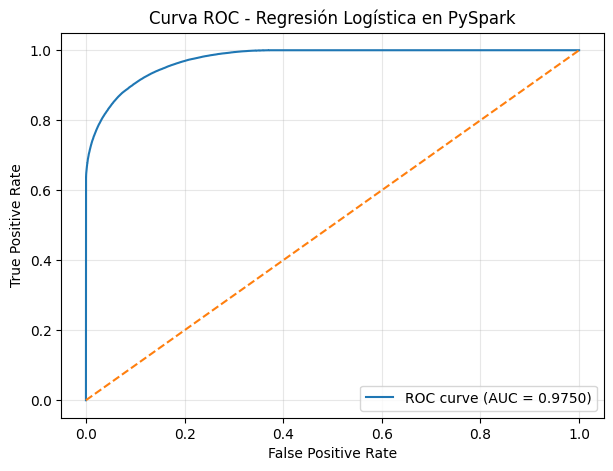

In [32]:
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Extraer label y probabilidad de la clase 1
roc_df = predictions.select(
    col("label"),
    vector_to_array("probability")[1].alias("prob_1")
)

# Pasar a pandas
roc_pd = roc_df.toPandas()

# Calcular curva ROC
fpr, tpr, thresholds = roc_curve(roc_pd["label"], roc_pd["prob_1"])
roc_auc = auc(fpr, tpr)

# Graficar
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Regresión Logística en PySpark")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()